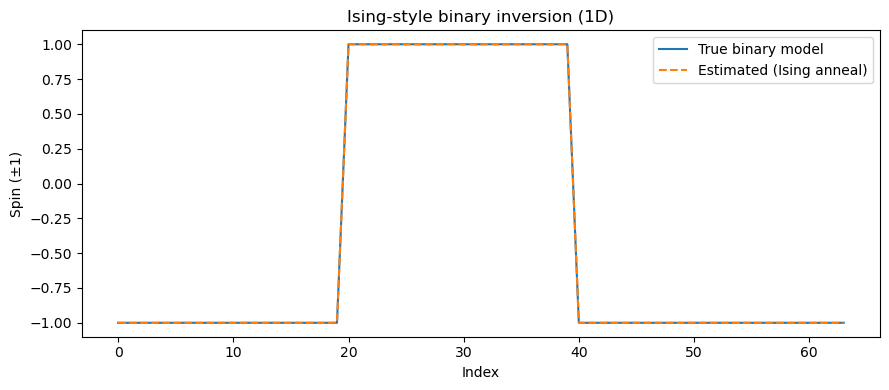

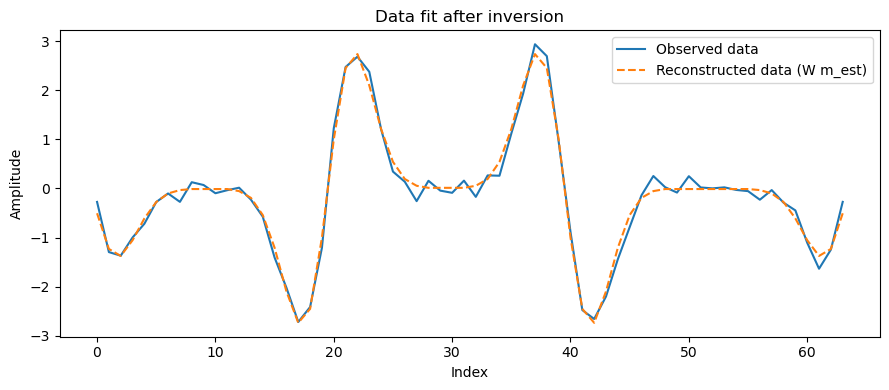

Initial energy: 175.25
Final energy:   -92.89
Accepted flips: 310


In [1]:
# Ising-style 1D binary inversion demo with simulated annealing
# Goal: recover a binary (±1) "layer" model m from band-limited data d = W m + noise,
# where W is a convolution with a short wavelet. The energy is:
#   E(m) = ||W m - d||^2 + lambda * sum_i (1 - m_i m_{i+1})   (Ising pairwise term)
# We minimize E(m) over m_i ∈ {±1} using a simple Metropolis simulated annealer.

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)

# --- 1) Build a synthetic binary model (±1) ---
N = 64
m_true = -np.ones(N)
m_true[20:40] = 1  # a "plume-like" block

# --- 2) Define a short zero-phase wavelet and build convolution operator W ---
def ricker(f0, dt, nt):
    t = (np.arange(nt) - (nt - 1) / 2) * dt
    a = (np.pi * f0 * t) ** 2
    w = (1 - 2 * a) * np.exp(-a)
    return w

dt = 0.004
w = ricker(f0=25.0, dt=dt, nt=17)  # short, band-limited
L = len(w)

# Toeplitz-like convolution matrix (valid/zero-padded conv)
# W shape: (N, N); y = W @ m computes zero-padded 1D conv of w with m (centered)
W = np.zeros((N, N))
half = L // 2
for i in range(N):
    for k in range(L):
        j = i - half + k
        if 0 <= j < N:
            W[i, j] = w[k]

# --- 3) Generate data and add noise ---
d_clean = W @ m_true
noise = 0.05 * np.max(np.abs(d_clean)) * np.random.randn(N)
d = d_clean + noise

# --- 4) Define Ising-style energy ---
lam = 1.0  # pairwise coupling weight (smoothness / compactness)
WTW = W.T @ W
WTd = W.T @ d  # used for fast energy updates

def energy(m):
    # Data misfit term = ||Wm - d||^2 = m^T W^T W m - 2 d^T W m + d^T d
    misfit = m @ (WTW @ m) - 2 * (WTd @ m)
    # Ising pairwise: sum (1 - m_i m_{i+1}) promotes neighboring spins to align
    pair = np.sum(1.0 - m[:-1] * m[1:])
    return misfit + lam * pair

# --- 5) Simulated annealing over spins m_i ∈ {±1} ---
def anneal(m0, T0=2.0, T_min=1e-3, alpha=0.98, iters_per_T=200):
    m = m0.copy()
    E = energy(m)
    T = T0
    Nacc = 0
    while T > T_min:
        for _ in range(iters_per_T):
            i = np.random.randint(0, N)
            m_new = m.copy()
            m_new[i] *= -1  # flip one spin
            E_new = energy(m_new)
            dE = E_new - E
            if dE <= 0 or np.random.rand() < np.exp(-dE / T):
                m = m_new
                E = E_new
                Nacc += 1
        T *= alpha
    return m, E, Nacc

# Initialize with random spins
m0 = np.where(np.random.rand(N) > 0.5, 1.0, -1.0)
m_est, E_final, Nacc = anneal(m0, T0=3.0, T_min=1e-3, alpha=0.97, iters_per_T=400)

# --- 6) Plot true vs estimated model and the data fit ---
plt.figure(figsize=(9, 4))
plt.plot(m_true, label="True binary model")
plt.plot(m_est, linestyle="--", label="Estimated (Ising anneal)")
plt.title("Ising-style binary inversion (1D)")
plt.xlabel("Index")
plt.ylabel("Spin (±1)")
plt.legend()
plt.tight_layout()
plt.show()

# Plot data vs reconstruction
d_est = W @ m_est
plt.figure(figsize=(9, 4))
plt.plot(d, label="Observed data")
plt.plot(d_est, linestyle="--", label="Reconstructed data (W m_est)")
plt.title("Data fit after inversion")
plt.xlabel("Index")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()

E0 = energy(m0)
E1 = energy(m_est)

print(f"Initial energy: {E0:.2f}")
print(f"Final energy:   {E1:.2f}")
print(f"Accepted flips: {Nacc}")
